# Fit Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.base import clone

from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm

from bioacoustics.features import augment_temporal_features, augment_sites

from bioacoustics.data import load_results, save_results
from bioacoustics.metrics import evaluate_multilabel_model

from bioacoustics.modeling import FitMode, Classifier, HierarchicalMixtureOfExperts
from bioacoustics.modeling import split_data, get_prediction_pipeline, select_classifier
from bioacoustics.modeling import smooth_proba, gs_results_to_df

from bioacoustics.modeling import get_feature_importance
from bioacoustics.modeling import ignore_warnings

import bioacoustics.visualization as viz

ignore_warnings()  # TODO: fix the reasons for these warnings

%load_ext autoreload
%autoreload 2

/Users/vlad/Documents/University/Master-MIND/bioacoustic-species-detection/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Problems to think about:

- Multi-label prediction -> hierarchical models? implement with `Pipeline`
- Class imbalance -> tinker with class weights, adjust probabilities?
- Use additional metadata from train, not available in soundscapes
- Maybe use hybrid approaches? learn about how to combine different models' predictions

think about chunking the audio, tuning the threshold for ech class

## Load features and labels

In [5]:
data_train = load_results("features", "data_train")
data_train_soundscapes = load_results("features", "data_train_soundscapes")
data_train_soundscapes_embeddings = load_results("features", "data_train_soundscapes", "embeddings")

# Decided to not keep them as the gain in ROC-AUC is
# marginal (~1%) and they introduce potential recording bias
AUGMENT_WITH_TIME = False
AUGMENT_WITH_SITES = False

if AUGMENT_WITH_TIME:
    data_train_soundscapes["X"] = augment_temporal_features(data_train_soundscapes["X"])
    data_train_soundscapes_embeddings ["X"] = augment_temporal_features(data_train_soundscapes_embeddings ["X"])
if AUGMENT_WITH_SITES:
    data_train_soundscapes["X"] = augment_sites(data_train_soundscapes["X"])
    data_train_soundscapes_embeddings ["X"] = augment_sites(data_train_soundscapes_embeddings ["X"])

Note that it doesn't make much sense to validate on iNat or XC data, since it's of different format than test soundscapes.

In [41]:
FIT_MODE = FitMode.MIX_TO_SOUNDSCAPE # SOUNDSCAPE_TO_SOUNDSCAPE or MIX_TO_SOUNDSCAPE
USE_EMBEDDINGS = True

if USE_EMBEDDINGS and FIT_MODE != FitMode.SOUNDSCAPE_TO_SOUNDSCAPE:
    print("embeddings were obtained ony for soundscapes")
    USE_EMBEDDINGS = False

X_train_feat, X_test_feat, y_class_train, y_class_test, y_primary_train, y_primary_test = (
    split_data(
        data_train,
        data_train_soundscapes,
        FIT_MODE,
        test_size=0.2,
        random_state=41,
        rare_first=False,
    )
)

if USE_EMBEDDINGS:
    X_train_embed = data_train_soundscapes_embeddings["X"].loc[X_train_feat.index]
    X_test_embed = data_train_soundscapes_embeddings["X"].loc[X_test_feat.index]

embeddings were obtained ony for soundscapes


About metrics:

The metric they use in BirdClef is macro ROC-AUC a a version of
macro-averaged ROC-AUC that skips classes that have no true positive labels.

- Macro - metric computed per class then averaged, giving each label
equal weight regardless of frequency.

- Micro - metric computed globally by aggregating all true positives,
false positives, and false negatives across labels.

- Hamming loss - fraction of incorrectly predicted label assignments
across all samples and labels.

- LRAP (Label Ranking Average Precision) - evaluates how well true
labels are ranked above others for each sample; averages the rank
quality over true labels and samples.

- Macro metrics are computed only over classes that have at least one
positive sample in the test set; zero-support classes would make
roc_auc_score return NaN and contribute uninformative zeros to F1.

In [42]:
SMOOTH_SIGMA = 0 # 0 if no smoothing

## Baseline species prediction

This is the model we are using for hyperparameter tuning and model selection with cross validation on train set only. 

MoE will use the model selected with cross-validation on the train set.

The validation set defined above is used for final validation and test on more resource-consuming approaches such as MoE.

**On features** we try ensemble models, as they are expected to handle good non-linear feature data: 
- XGBoost
- Random Forest 

**On embeddings** we try linear models, since the `Perch 2.0` was pre-trained so that obtained embeddings are linearly separable.
- Ridge Logistic Regression
- SVM

In [ ]:
feature_param_grids = {
    Classifier.XGBOOST: {
        "clf__estimator__max_depth":     [3, 5],
        "clf__estimator__n_estimators":  [100, 300],
        "clf__estimator__learning_rate": [0.05, 0.1],
        # 2×2×2 = 8 candidates, 24 fits
    },
    Classifier.RF: {
        "clf__estimator__max_depth":        [10, None],
        "clf__estimator__max_features":     ["sqrt", 0.3],
        "clf__estimator__min_samples_leaf": [1, 3],
        # 2×2×2 = 8 candidates, 24 fits
    },
}

embedding_param_grids = {
    Classifier.LR: {
        "clf__estimator__C":            [0.01, 0.1, 1.0, 10.0],
        "clf__estimator__class_weight": ["balanced", None],
        # 4×2 = 8 candidates, 24 fits
    },
    Classifier.SVM: {
        "clf__estimator__C":            [0.1, 1.0, 10.0, 100.0],
        "clf__estimator__class_weight": ["balanced", None],
        # 4×2 = 8 candidates, 24 fits
    },
}

best_feature_clf, best_feature_params, feature_gs = select_classifier(
    X_train_feat, y_primary_train, feature_param_grids
)

if USE_EMBEDDINGS:
    best_embed_clf, best_embed_params, embed_gs = select_classifier(
        X_train_embed, y_primary_train, embedding_param_grids
    )

In [ ]:
save_results(gs_results_to_df(feature_gs), f"gs-{FIT_MODE.name.lower()}-features")

if USE_EMBEDDINGS:
    save_results(gs_results_to_df(embed_gs), f"gs-{FIT_MODE.name.lower()}-embeddings")

In [ ]:
best_embed_params

{<Classifier.LR: 2>: GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
              estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                        ('scaler', StandardScaler()),
                                        ('clf',
                                         OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                                          l1_ratio=0,
                                                                                          max_iter=1000,
                                                                                          tol=0.01),
                                                             n_jobs=1))]),
              n_jobs=5,
              param_grid={'clf__estimator__C': [0.01, 0.1, 1.0, 10.0],
                          'clf__estimator__class_weight': ['balanced', None]},
              refit=False,
              scor

In [45]:
CHOOSE_FEATURES = True

assert CHOOSE_FEATURES or USE_EMBEDDINGS, "only features were used"

if CHOOSE_FEATURES:
    CLASSIFIER = best_feature_clf  
    best_params = best_feature_params
    X_train = X_train_feat
    X_test = X_test_feat
else:
    CLASSIFIER = best_embed_clf  
    best_params = best_embed_params
    X_train = X_train_embed
    X_test = X_test_embed

In [46]:
pipeline_baseline = get_prediction_pipeline(CLASSIFIER, **best_params)
with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_baseline.fit(X_train, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [47]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(ignore CLASS)".center(60))
eval_report_baseline = evaluate_multilabel_model(pipeline_baseline, X_test, y_primary_test)
save_results(eval_report_baseline, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_baseline")

            MIX_TO_SOUNDSCAPE predicting SPECIES            
                       (ignore CLASS)                       
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0323  over 34 classes: 0.2224
Micro F1:     0.3991
Hamming loss: 0.0150

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.7971
Micro ROC AUC: 0.9243
Macro AP:      0.0673  over 34 classes: 0.4630
Micro AP:      0.4818
LRAP:          0.5840


## Taxonomy to predict species

We can use these approaches:

1. **Hierarchical classification:**
    - first predict the class and then train per-class model
    - we must avoid training mismatch - at inference predicted class is used, but at training use only true class, so we better condition on predicted class
    - problems:
        - error propagation if predicted class is wrong
    - **soft version:**
        - $P(s|x) = \sum_c P(s|x,c)P(c|x)$
        - predict class probabilities and use them as soft weights for species classifiers
        - i.e. mixture of experts, soft routing
        - pros:
            - avoids routing errors
            - more consistent as a probability model
    - multilabel problem:
        - since data is multilabel, classes are not mutually exclusive, it means that when we do an averages sum of preicted probabilities, it will not sum to 1
        - so we would need to normalize it or just do average prediction across experts

1. **Feature augmentation**
    - include predicted class as a new feature:
    - no hard routing, so more robust
    - simple to implement
    - problems:
        - this feature can be noisy
    - **soft version:**
        - include predicted class probabilities as new features
    - ideas:
        - I'm afraid class signal will be hidden by hundreds of features, maybe we should emphasize it?

1. Other ideas:
    - hierarchical loss (penalize wrong species but good class less)

We would focus on soft approaches as they are more robust since they avoid noisy hard class assignment.

### Predict class



In [48]:
pipeline_class = get_prediction_pipeline(CLASSIFIER)
with tqdm_joblib(desc="Training OvR", total=y_class_train.shape[1]):
    pipeline_class.fit(X_train, y_class_train)

Training OvR:   0%|          | 0/5 [00:00<?, ?it/s]

In [49]:
print(f"{FIT_MODE.name} predicting CLASS".center(60))
eval_report = evaluate_multilabel_model(pipeline_class, X_test, y_class_test)
save_results(eval_report, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-class")

             MIX_TO_SOUNDSCAPE predicting CLASS             

================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

    Amphibia       0.99      0.59      0.74       116
        Aves       0.45      0.91      0.60        56
     Insecta       1.00      0.94      0.97        36
    Mammalia       0.00      0.00      0.00         2
    Reptilia       0.00      0.00      0.00         4

   micro avg       0.71      0.71      0.71       214
   macro avg       0.49      0.49      0.46       214
weighted avg       0.82      0.71      0.72       214
 samples avg       0.65      0.68      0.64       214


================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.4613
Micro F1:     0.7100
Hamming loss: 0.1613

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: 0.9726411378794746
Micro ROC AUC: 0.9416
Macro AP:      0.9773
Micro AP:      0.8630
LRAP:          0.8468


In [50]:
N_FOLDS = 5

# use out-of-fold (OOF) prediction unbiased class probabilities for training samples
y_class_train_proba = cross_val_predict(
    clone(pipeline_class), X_train, y_class_train,
    cv=KFold(n_splits=N_FOLDS, shuffle=True, random_state=42),
    method="predict_proba",
)
y_class_test_proba = pipeline_class.predict_proba(X_test)

### Soft hierarchical classification

In [51]:
expert_pipelines = HierarchicalMixtureOfExperts(y_class_test.shape[1], CLASSIFIER)
expert_pipelines.fit(X_train, y_class_train, y_primary_train)

Training expert for Amphibia  :   0%|          | 0/44 [00:00<?, ?it/s]

Training expert for Aves      :   0%|          | 0/190 [00:00<?, ?it/s]

Training expert for Insecta   :   0%|          | 0/49 [00:00<?, ?it/s]

Training expert for Mammalia  :   0%|          | 0/25 [00:00<?, ?it/s]

Training expert for Reptilia  :   0%|          | 0/22 [00:00<?, ?it/s]

In [52]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(soft mixture of CLASS experts)".center(60))
eval_report_moe = evaluate_multilabel_model(expert_pipelines, X_test, y_primary_test, y_class_test_proba)
save_results(eval_report_moe, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_moe")

            MIX_TO_SOUNDSCAPE predicting SPECIES            
              (soft mixture of CLASS experts)               
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0216  over 34 classes: 0.1484
Micro F1:     0.2861
Hamming loss: 0.0151

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8022
Micro ROC AUC: 0.9421
Macro AP:      0.0691  over 34 classes: 0.4752
Micro AP:      0.5041
LRAP:          0.6008


### Soft feature augmentation

In [53]:
X_test_augmented = np.concatenate([X_test, y_class_test_proba], axis=1)
X_train_augmented = np.concatenate([X_train, y_class_train_proba], axis=1)

pipeline_augmentation = get_prediction_pipeline(CLASSIFIER)

with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_augmentation.fit(X_train_augmented, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [54]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(CLASS feature augmentation)".center(60))
eval_report_aug = evaluate_multilabel_model(pipeline_augmentation, X_test_augmented, y_primary_test)
save_results(eval_report_aug, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_feat_augmentation")

            MIX_TO_SOUNDSCAPE predicting SPECIES            
                (CLASS feature augmentation)                
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0239  over 34 classes: 0.1647
Micro F1:     0.3221
Hamming loss: 0.0150

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8098
Micro ROC AUC: 0.9270
Macro AP:      0.0678  over 34 classes: 0.4668
Micro AP:      0.4853
LRAP:          0.5863


In [55]:
def _flatten(df, name):
    """Convert a two-column eval report to a Series with disambiguated metric names."""
    rows = {}
    for metric in df.index:
        if "supported_classes" in df.columns:
            sup = df.loc[metric, "supported_classes"]
            all_ = df.loc[metric, "all_classes"]
            if pd.notna(sup):
                rows[f"{metric} (supported)"] = sup
                if pd.notna(all_):
                    rows[f"{metric} (all)"] = all_
            else:
                rows[metric] = all_
        else:
            rows[metric] = df.loc[metric, "value"]
    return pd.Series(rows, name=name)

species_comparison = pd.concat([
    _flatten(eval_report_baseline, "Baseline"),
    _flatten(eval_report_moe, "MoE"),
    _flatten(eval_report_aug, "Feat. augmentation"),
], axis=1)
species_comparison.index.name = "metric"
save_results(species_comparison, f"{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}-species_comparison")
species_comparison

,Baseline,MoE,Feat. augmentation
metric,,,
Macro F1 (supported),0.222403,0.148425,0.164681
Macro F1 (all),0.032315,0.021566,0.023928
Micro F1,0.399118,0.286086,0.322097
Hamming loss,0.015026,0.015136,0.014971
Macro ROC AUC (supported),0.797065,0.802214,0.809771
Micro ROC AUC,0.924308,0.942146,0.927039
Macro AP (supported),0.463019,0.475233,0.466849
Macro AP (all),0.067276,0.069051,0.067833
Micro AP,0.481755,0.504063,0.485251


## Interpret the model

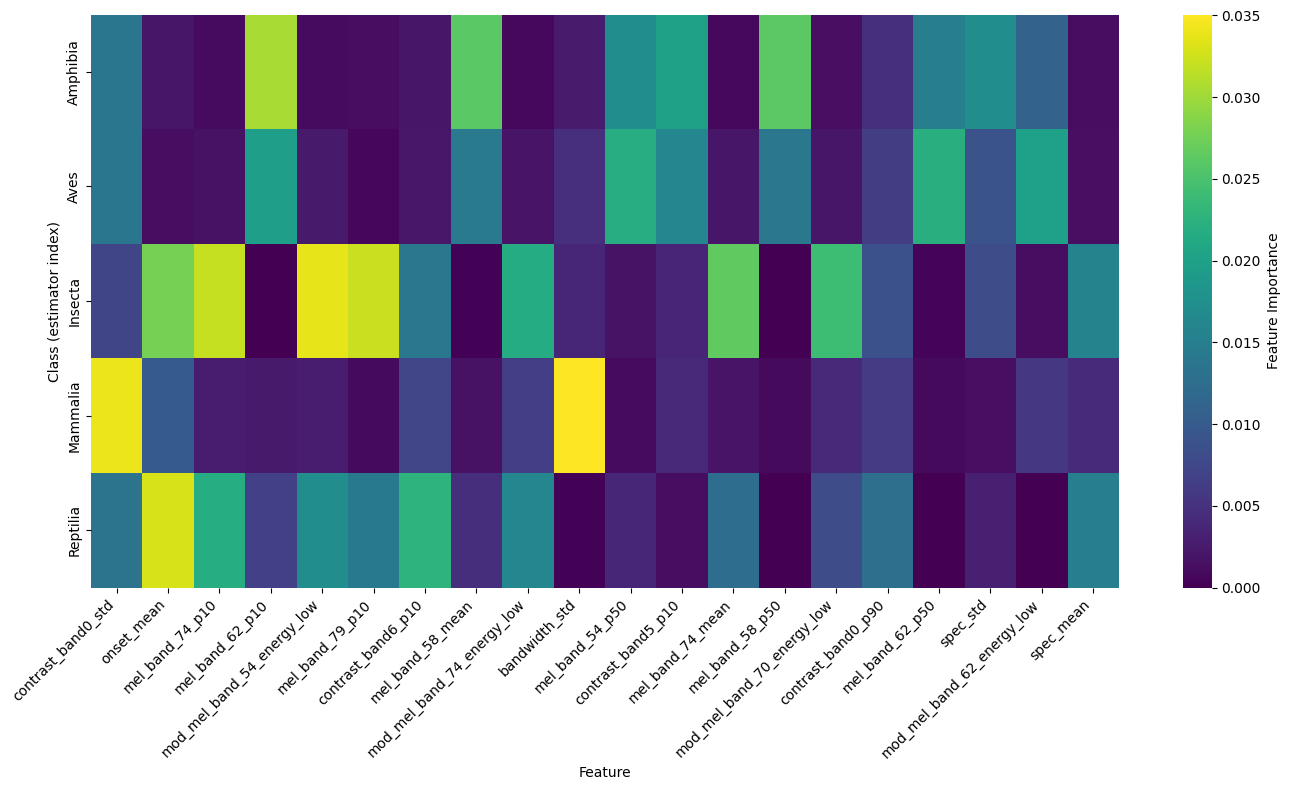

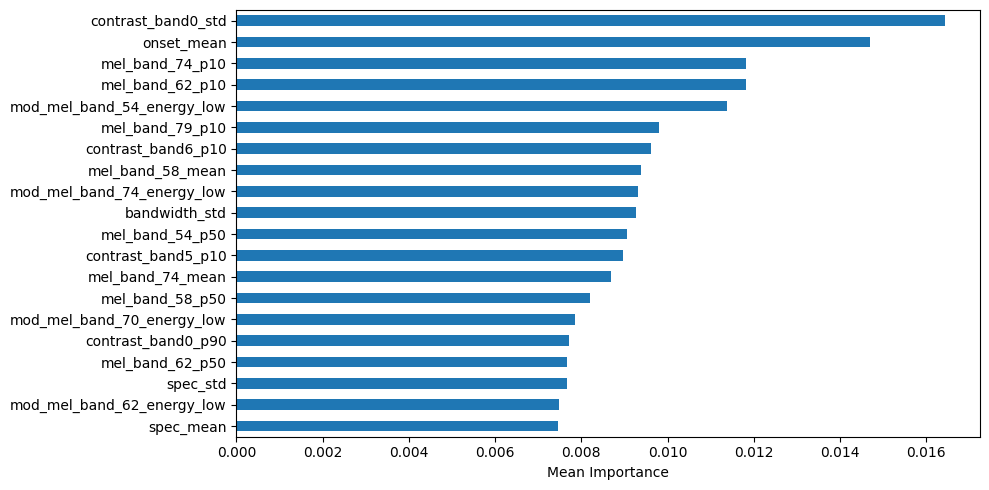

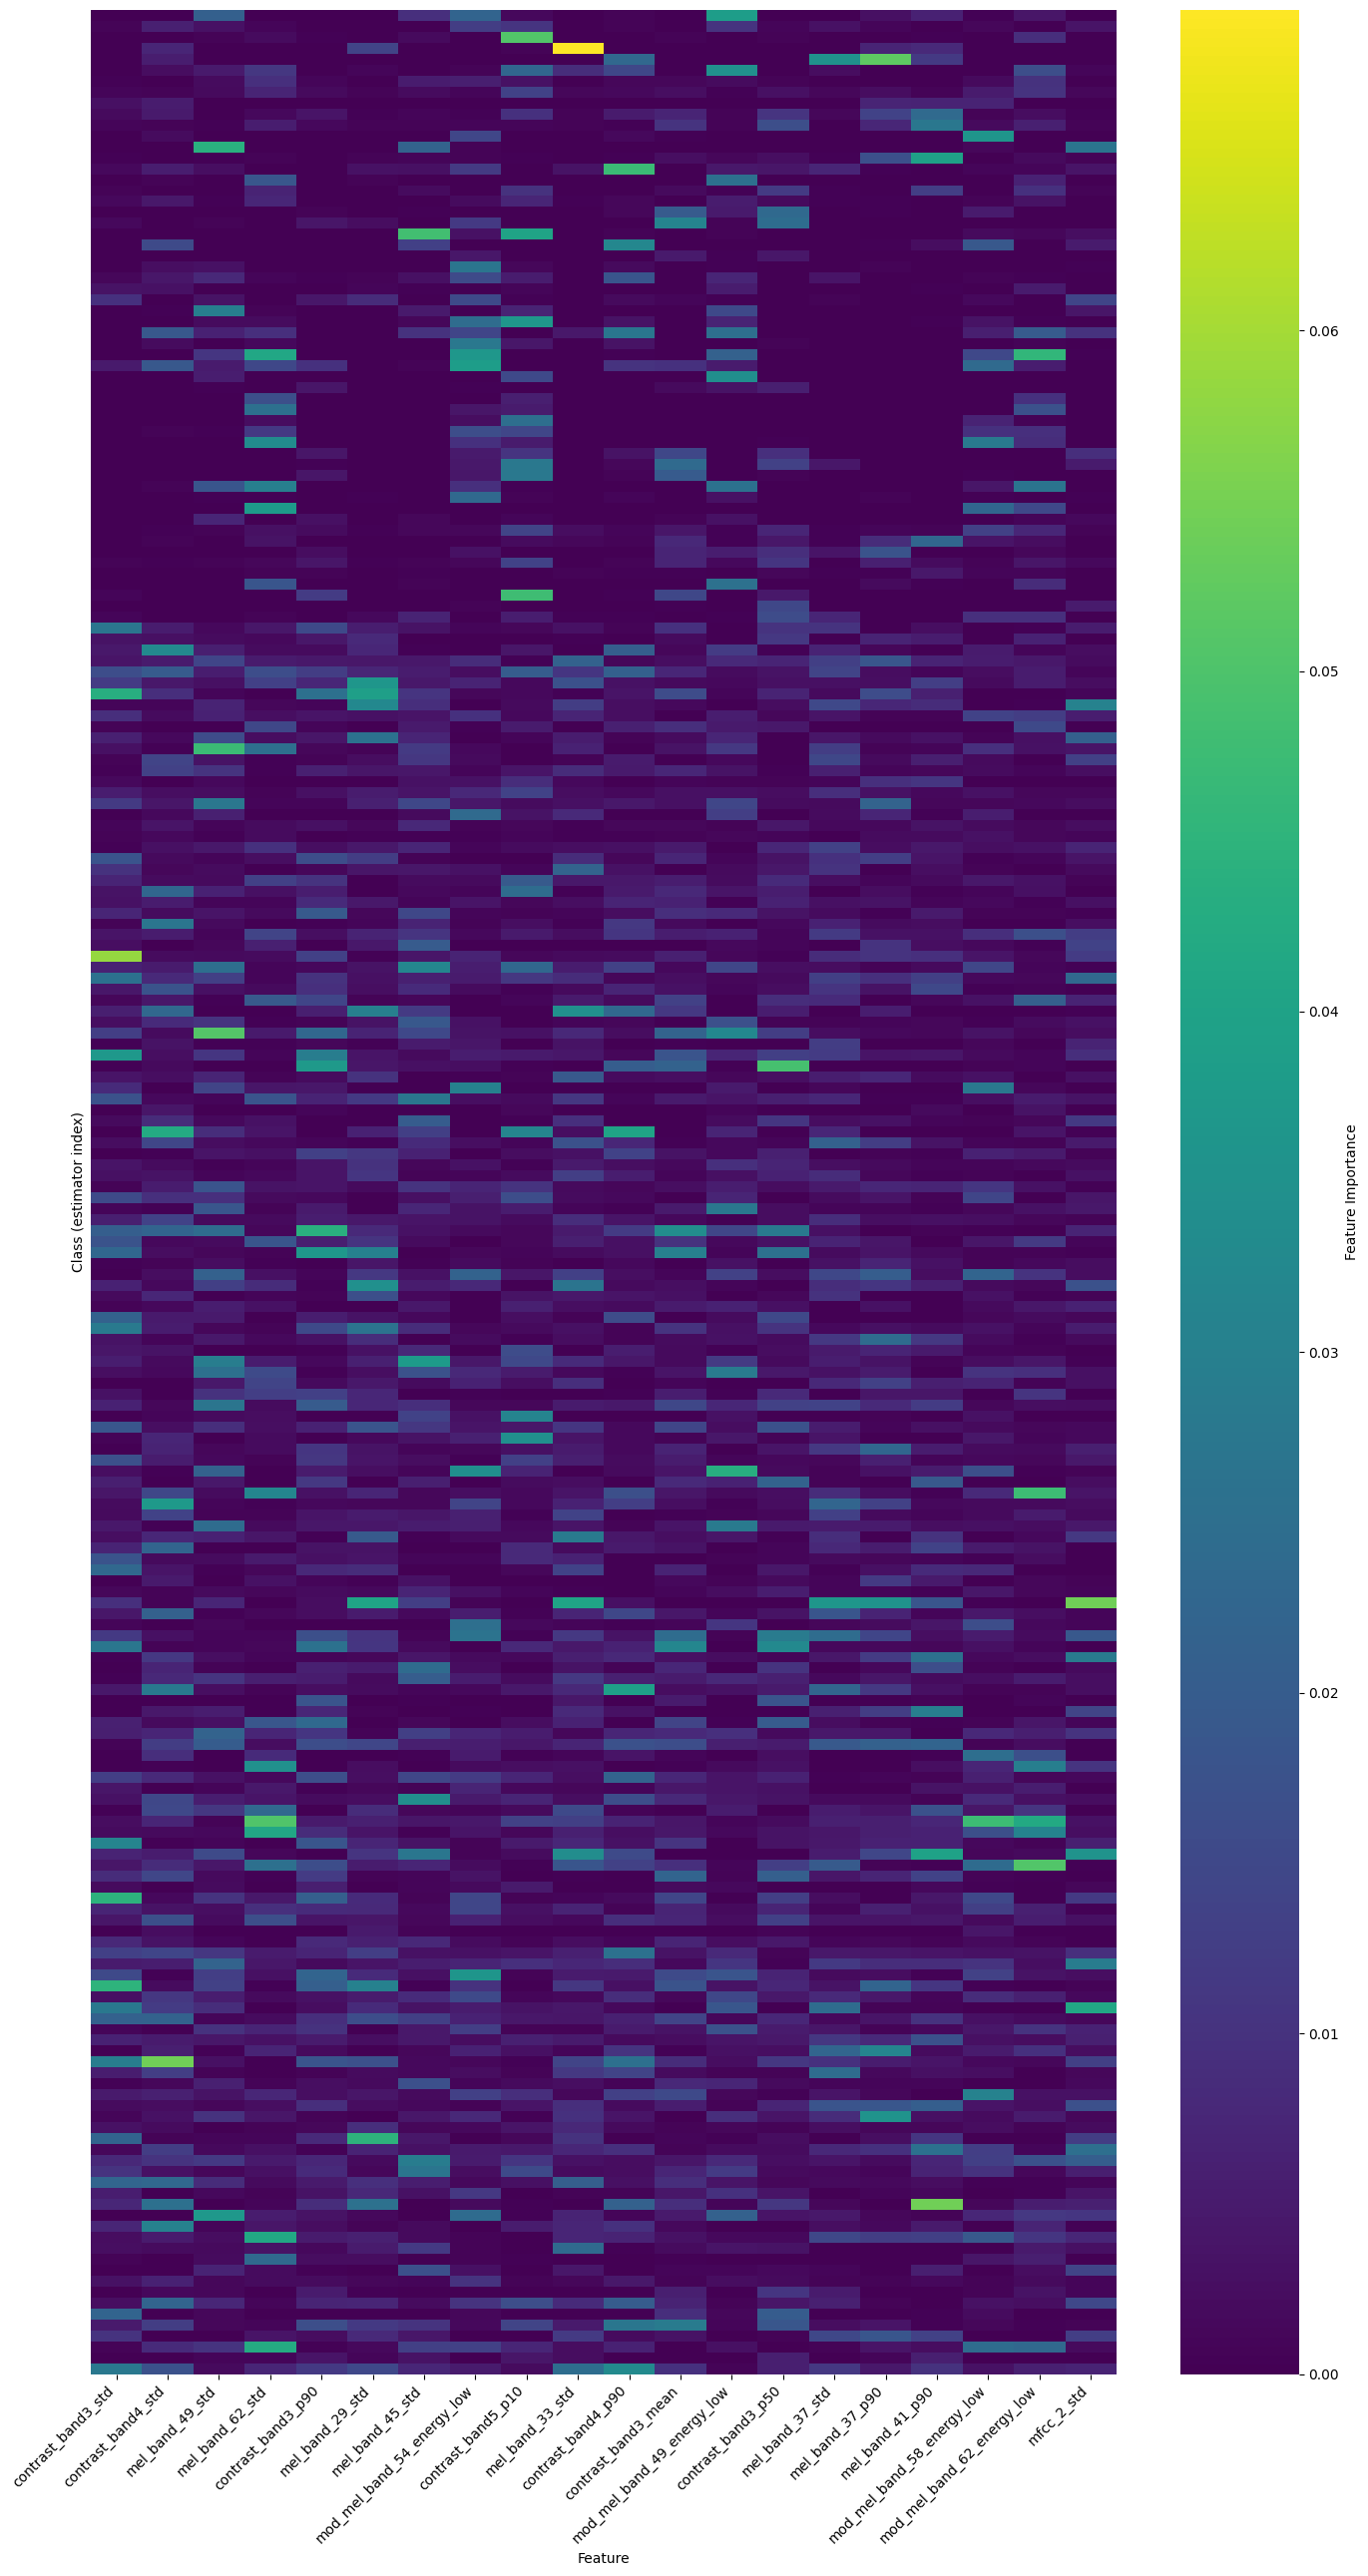

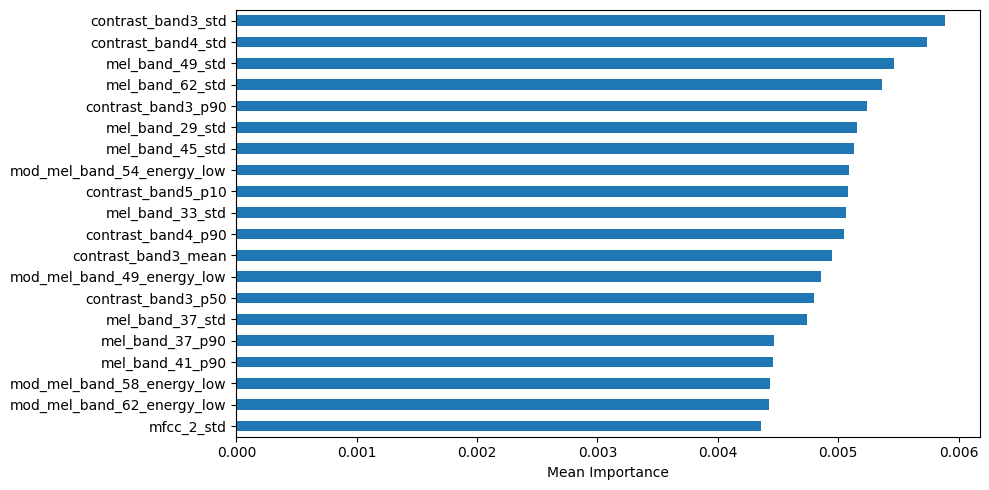

In [68]:
for pipeline, label_type in zip((pipeline_class, pipeline_baseline), ("class", "species")):
    class_names = y_class_train.columns
    primary_names = y_primary_train.columns
    df_importance = get_feature_importance(pipeline, class_names)
    TOP_N = 20
    viz.plot_importance_heatmap(df_importance, top_n=TOP_N)
    viz.savefig(f"feat_importance-{label_type}-{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}")
    plt.show()
    viz.plot_importance_mean(df_importance, top_n=TOP_N)
    viz.savefig(f"feat_importance_mean-{label_type}-{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}")
    plt.show()

## Closer inspection of errors

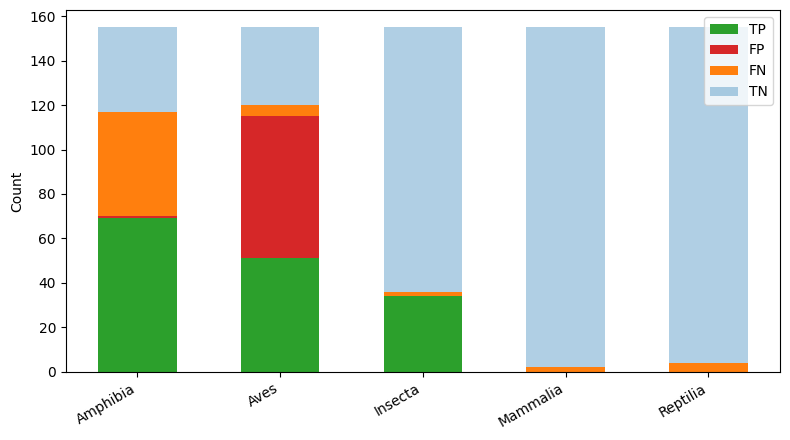

In [69]:
y_proba = pipeline_class.predict_proba(X_test)
# viz.plot_multilabel_errors(y_class_test, y_proba, threshold=0.5)
viz.plot_multilabel_confusion_breakdown(y_class_test, y_proba, threshold=0.5)
viz.savefig(f"confusion-class-{CLASSIFIER.name.lower()}-{FIT_MODE.name.lower()}")
plt.show()

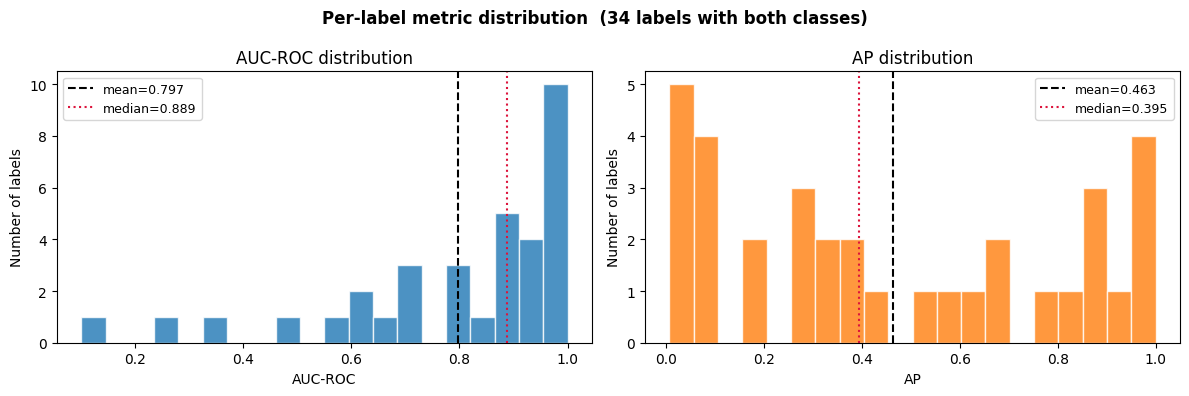

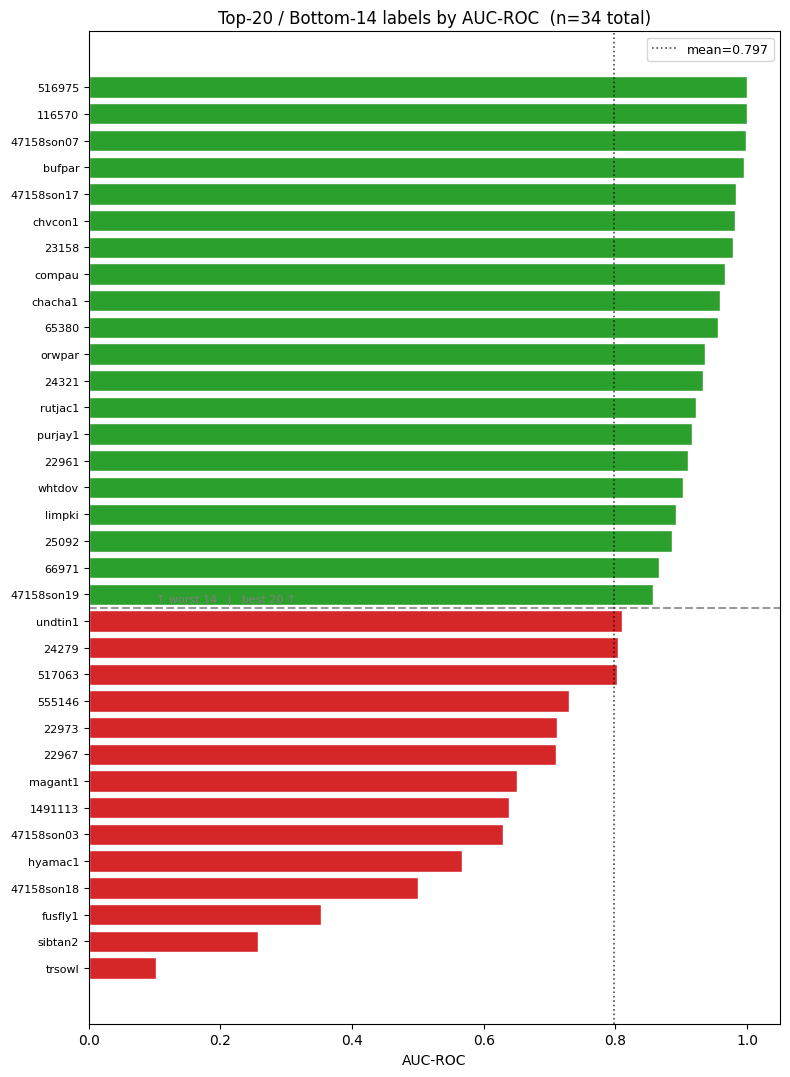

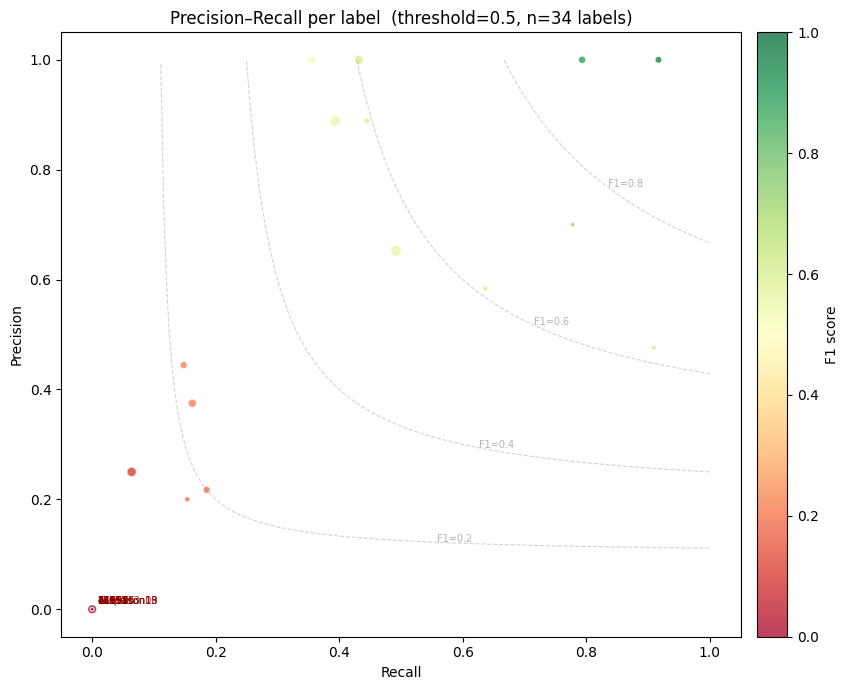

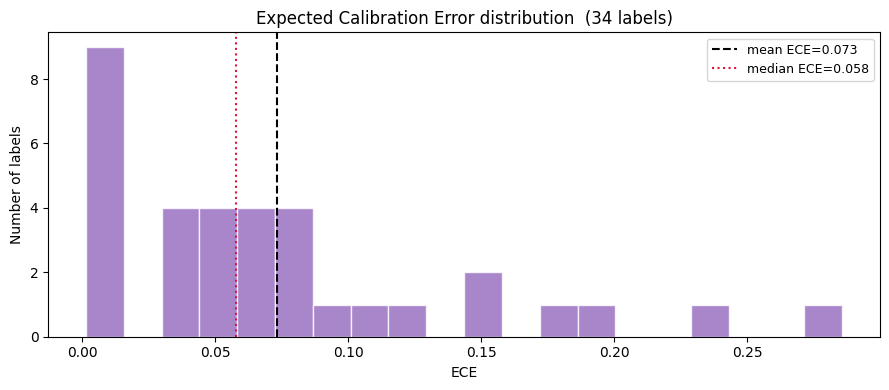

In [58]:
y_proba = pipeline_baseline.predict_proba(X_test)
viz.plot_multilabel_errors_large(y_primary_test, y_proba, threshold=0.5)

# SANDBOX

In [59]:
# TODO: the same idea for training metadata that is absent for the test
# - we can learn to predict this metadata as a secondary task and then include
# it in the model

# NOTE: attention to data leak between train - validation when using secondary tasks
# to generate features (class, metadata)

# TODO: can use this metadata as well for stratification - better split validation
# (make sure that there is no data leak because of the same site)
# TODO: check whether metadata alone can predict species (check for shortcut learning)

# TODO: smart cross validations

# TODO: quality of train audio from iNat and xeno-cant is poorer and further from test than train soundscapes,
#       so maybe we should use them only for species poorly covered by soundscapes

# TODO: impute some NaNs

# TODO: maybe stratify be species or sth else since train data had
#   too (really) many bird recordings, whereas soundscapes contain more amphibians

# TODO: maybe play with thresholds

# TODO: temporal smoothing of predicted probabilities!